In [1]:
import pandas as pd
import numpy as np

import shap

import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit

from xgboost import XGBRegressor

C:\Users\Sure\Desktop\MATI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train_df = pd.read_csv(
    "../data/processed/train_engineered.csv"
)

print(train_df.shape)

(61249, 54)


In [3]:
RUL_CAP = 125

train_df["RUL_capped"] = (
    train_df["RUL"]
    .clip(upper=RUL_CAP)
)

In [4]:
DROP_COLS = [
    "unit_number",
    "RUL",
    "RUL_capped",
    "max_cycle",
    "life_fraction"
]

features = [
    col
    for col in train_df.columns
    if col not in DROP_COLS
]

X = train_df[features]

y = train_df["RUL_capped"]

In [5]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, val_idx = next(
    splitter.split(
        X,
        y,
        groups=train_df["unit_number"]
    )
)

X_train = X.iloc[train_idx]
X_val = X.iloc[val_idx]

y_train = y.iloc[train_idx]
y_val = y.iloc[val_idx]

In [6]:
model = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [7]:
explainer = shap.TreeExplainer(
    model
)

sample = X_val.sample(
    2000,
    random_state=42
)

shap_values = explainer.shap_values(
    sample
)

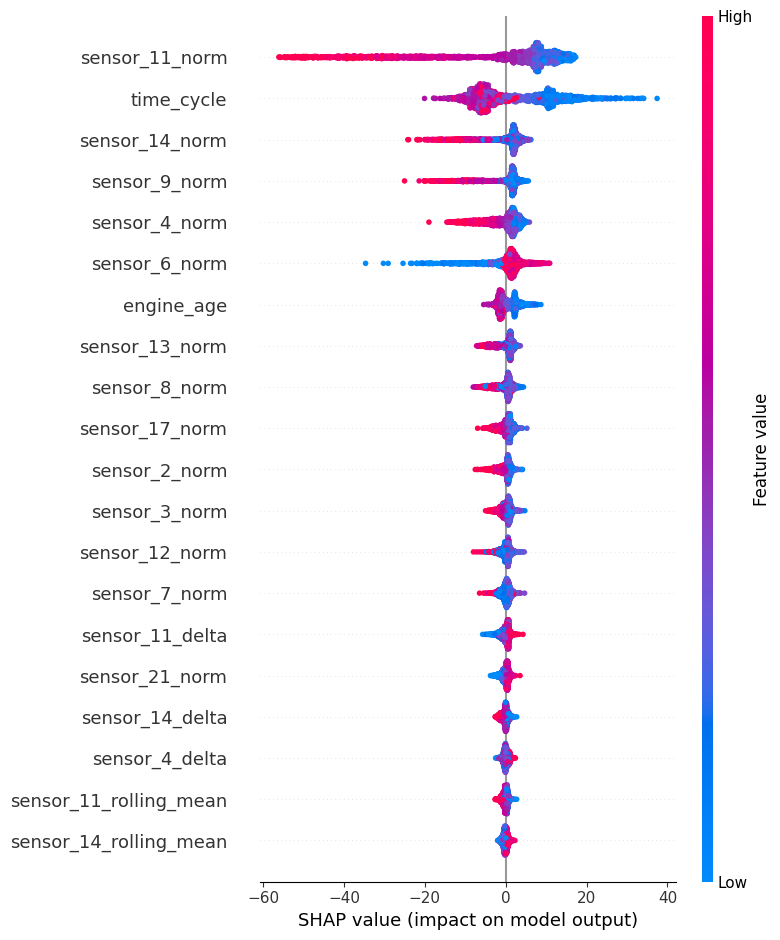

In [8]:
shap.summary_plot(
    shap_values,
    sample,
    show=False
)

plt.tight_layout()

plt.show()

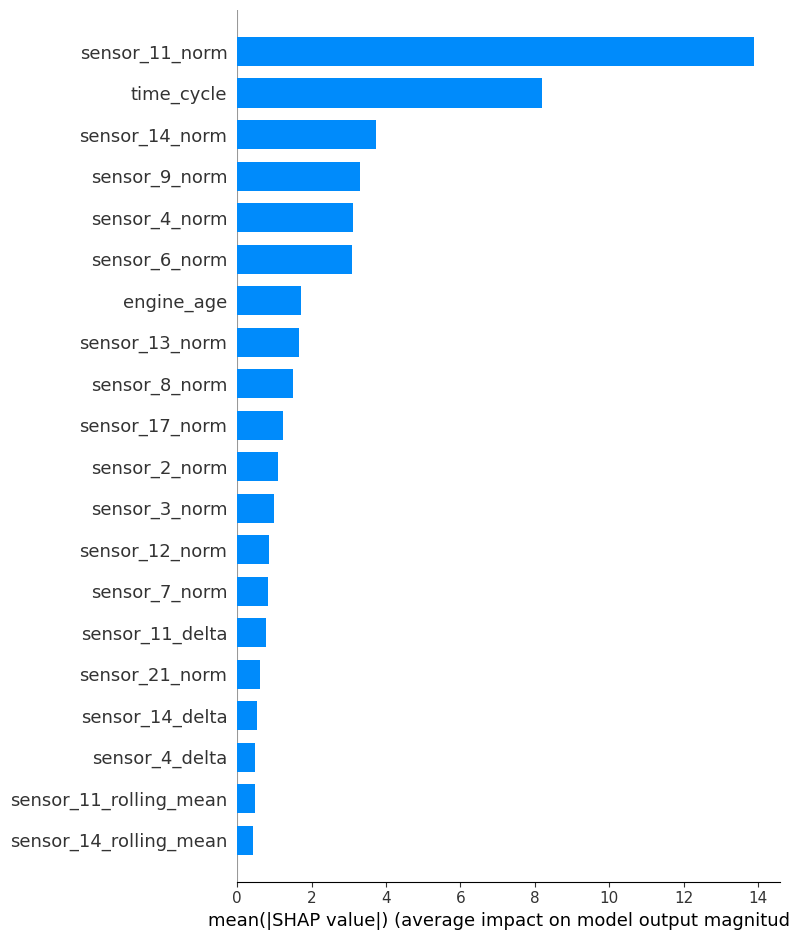

In [9]:
shap.summary_plot(
    shap_values,
    sample,
    plot_type="bar",
    show=False
)

plt.tight_layout()

plt.show()

In [10]:
importance = pd.DataFrame({
    "feature": sample.columns,
    "importance":
        np.abs(shap_values).mean(axis=0)
})

importance = (
    importance
    .sort_values(
        "importance",
        ascending=False
    )
)

importance.head(20)

,feature,importance
33,sensor_11_norm,13.888580
0,time_cycle,8.178879
36,sensor_14_norm,3.738911
32,sensor_9_norm,3.291817
27,sensor_4_norm,3.101780
29,sensor_6_norm,3.073085
22,engine_age,1.721716
35,sensor_13_norm,1.662540
31,sensor_8_norm,1.506052
37,sensor_17_norm,1.241615


In [13]:
sample_idx = y_val.sort_values().index[0]

sample_row = X.loc[[sample_idx]]

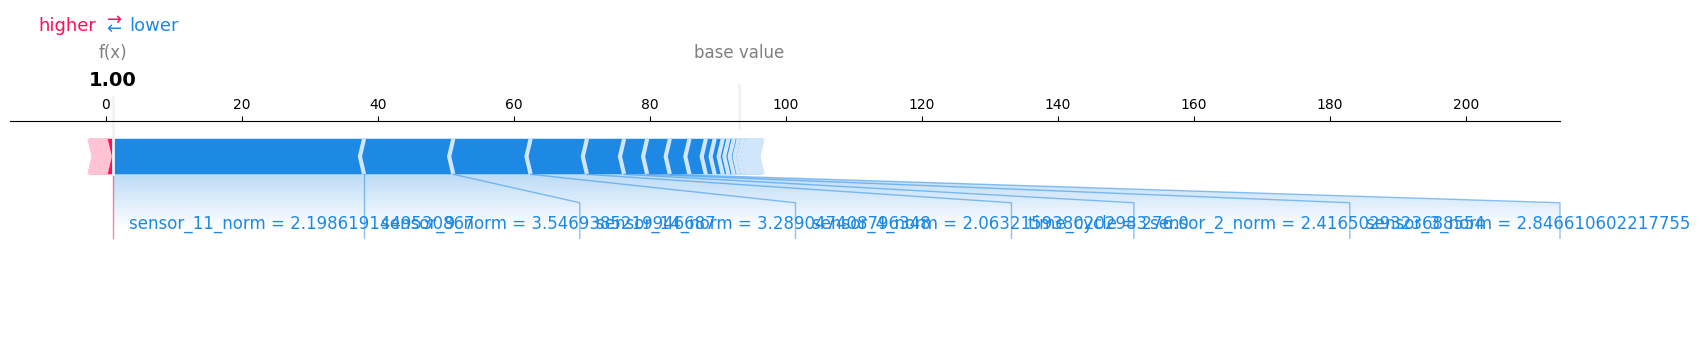

In [14]:
shap.force_plot(
    explainer.expected_value,
    explainer.shap_values(
        sample_row
    ),
    sample_row,
    matplotlib=True
)

# Root Cause Analysis

Top contributors to failure prediction:

1. sensor_11_norm
2. sensor_14_norm
3. sensor_9_norm
4. sensor_4_norm

Interpretation:

- Deviations in these telemetry signals are strong indicators of degradation.
- These sensors should be prioritized during inspection.
- SHAP explanations provide transparent maintenance recommendations.

In [15]:
importance.head(15)

,feature,importance
33,sensor_11_norm,13.888580
0,time_cycle,8.178879
36,sensor_14_norm,3.738911
32,sensor_9_norm,3.291817
27,sensor_4_norm,3.101780
29,sensor_6_norm,3.073085
22,engine_age,1.721716
35,sensor_13_norm,1.662540
31,sensor_8_norm,1.506052
37,sensor_17_norm,1.241615
